In [1]:
# importing required libraries
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
import missingno as mno
import warnings 
warnings.filterwarnings('ignore')
print('done')

done


In [2]:
# Evaluation parameters
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.dummy import DummyRegressor
# Model 1
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf
from sklearn.ensemble import BaggingRegressor

# Loading data sets

In [3]:
df_training = pd.read_csv(#)

In [4]:
df_training

,DEPT,NEUT,DENS,DTC,RESM,GR,PEF,WELLNAME
0,659.5872,0.34758,2.2471,118.2797,11.4703,92.1177,3.1998,Ahuroa South B-1
1,659.7396,0.32441,2.2503,118.0861,11.6295,92.9298,3.1848,Ahuroa South B-1
2,659.8920,0.30124,2.2536,117.8926,11.7887,93.7420,3.1698,Ahuroa South B-1
3,660.0444,0.29313,2.2543,117.8988,11.8483,94.4243,3.1683,Ahuroa South B-1
4,660.1968,0.32163,2.2487,118.3909,11.6656,94.7903,3.1999,Ahuroa South B-1
...,...,...,...,...,...,...,...,...
506739,1308.3540,0.32734,2.4787,96.4259,4.8998,116.0878,3.2800,Wawiri-1
506740,1308.5064,0.32727,2.4799,96.5073,4.8998,116.5207,3.3053,Wawiri-1
506741,1308.6588,0.31979,2.4799,96.2745,4.9318,116.8138,3.3180,Wawiri-1
506742,1308.8112,0.31231,2.4798,96.0416,4.9637,117.1069,3.3306,Wawiri-1


In [5]:
df_training.describe()

,DEPT,NEUT,DENS,DTC,RESM,GR,PEF
count,506744.000000,506744.000000,506744.000000,506744.000000,506744.000000,506744.000000,506744.000000
mean,2427.138163,0.243249,2.455541,86.018879,3097.067865,88.475727,3.540840
std,1279.757814,0.097341,0.179496,18.811766,55433.645571,25.172431,1.152419
min,257.556000,0.000050,0.799980,4.169300,0.435400,0.019300,0.100000
25%,1320.393600,0.185160,2.370100,72.139550,3.780700,70.765325,3.048200
50%,2211.933600,0.252860,2.485500,82.518150,6.573650,91.035000,3.364300
75%,3532.936800,0.310930,2.579600,97.403825,13.138725,106.185450,3.781000
max,5634.990000,0.947500,2.991800,249.036900,1000000.000000,199.490000,73.103900


In [6]:
test_well1 = pd.read_csv(#)

In [7]:
test_well1.describe()

,DEPT,NEUT,DENS,DTC,RESM,GR,PEF
count,17662.000000,17662.000000,17662.000000,17662.000000,17662.000000,17662.000000,17662.000000
mean,2693.496977,0.251133,2.505404,84.621864,6.913616,80.800868,3.726584
std,777.389886,0.044312,0.098335,7.434489,8.497438,16.415708,0.317891
min,1347.520800,0.058040,1.298100,54.199700,1.398400,11.033600,1.713600
25%,2020.404900,0.226190,2.486625,81.709400,3.097325,69.979725,3.597100
50%,2693.289000,0.253255,2.522100,84.143850,5.015700,78.335250,3.748800
75%,3366.173100,0.276767,2.559200,86.858825,6.330575,89.991900,3.882100
max,4051.858800,0.714880,2.829500,146.610700,175.313100,159.687700,7.943000


In [8]:
test_well2 = pd.read_csv(#)

In [9]:
test_well2.describe()

,DEPT,NEUT,DENS,DTC,RESM,GR,PEF
count,9706.000000,9706.000000,9706.000000,9706.000000,9706.000000,9706.000000,9706.000000
mean,1526.770034,0.308364,2.398546,98.976379,8.459440,103.379970,3.273926
std,427.295724,0.032098,0.089134,10.581683,4.720314,12.508656,0.201229
min,786.536400,0.132770,2.198700,57.563800,2.370500,48.511600,2.598200
25%,1156.906500,0.285232,2.329125,87.972050,5.110875,95.267400,3.136600
50%,1526.971800,0.312390,2.385350,99.500850,6.463550,105.108300,3.302500
75%,1896.732300,0.332150,2.493400,107.620125,11.637550,112.688800,3.417700
max,2266.492800,0.405940,2.702900,129.858300,54.925600,166.205200,4.331000


<Axes: >

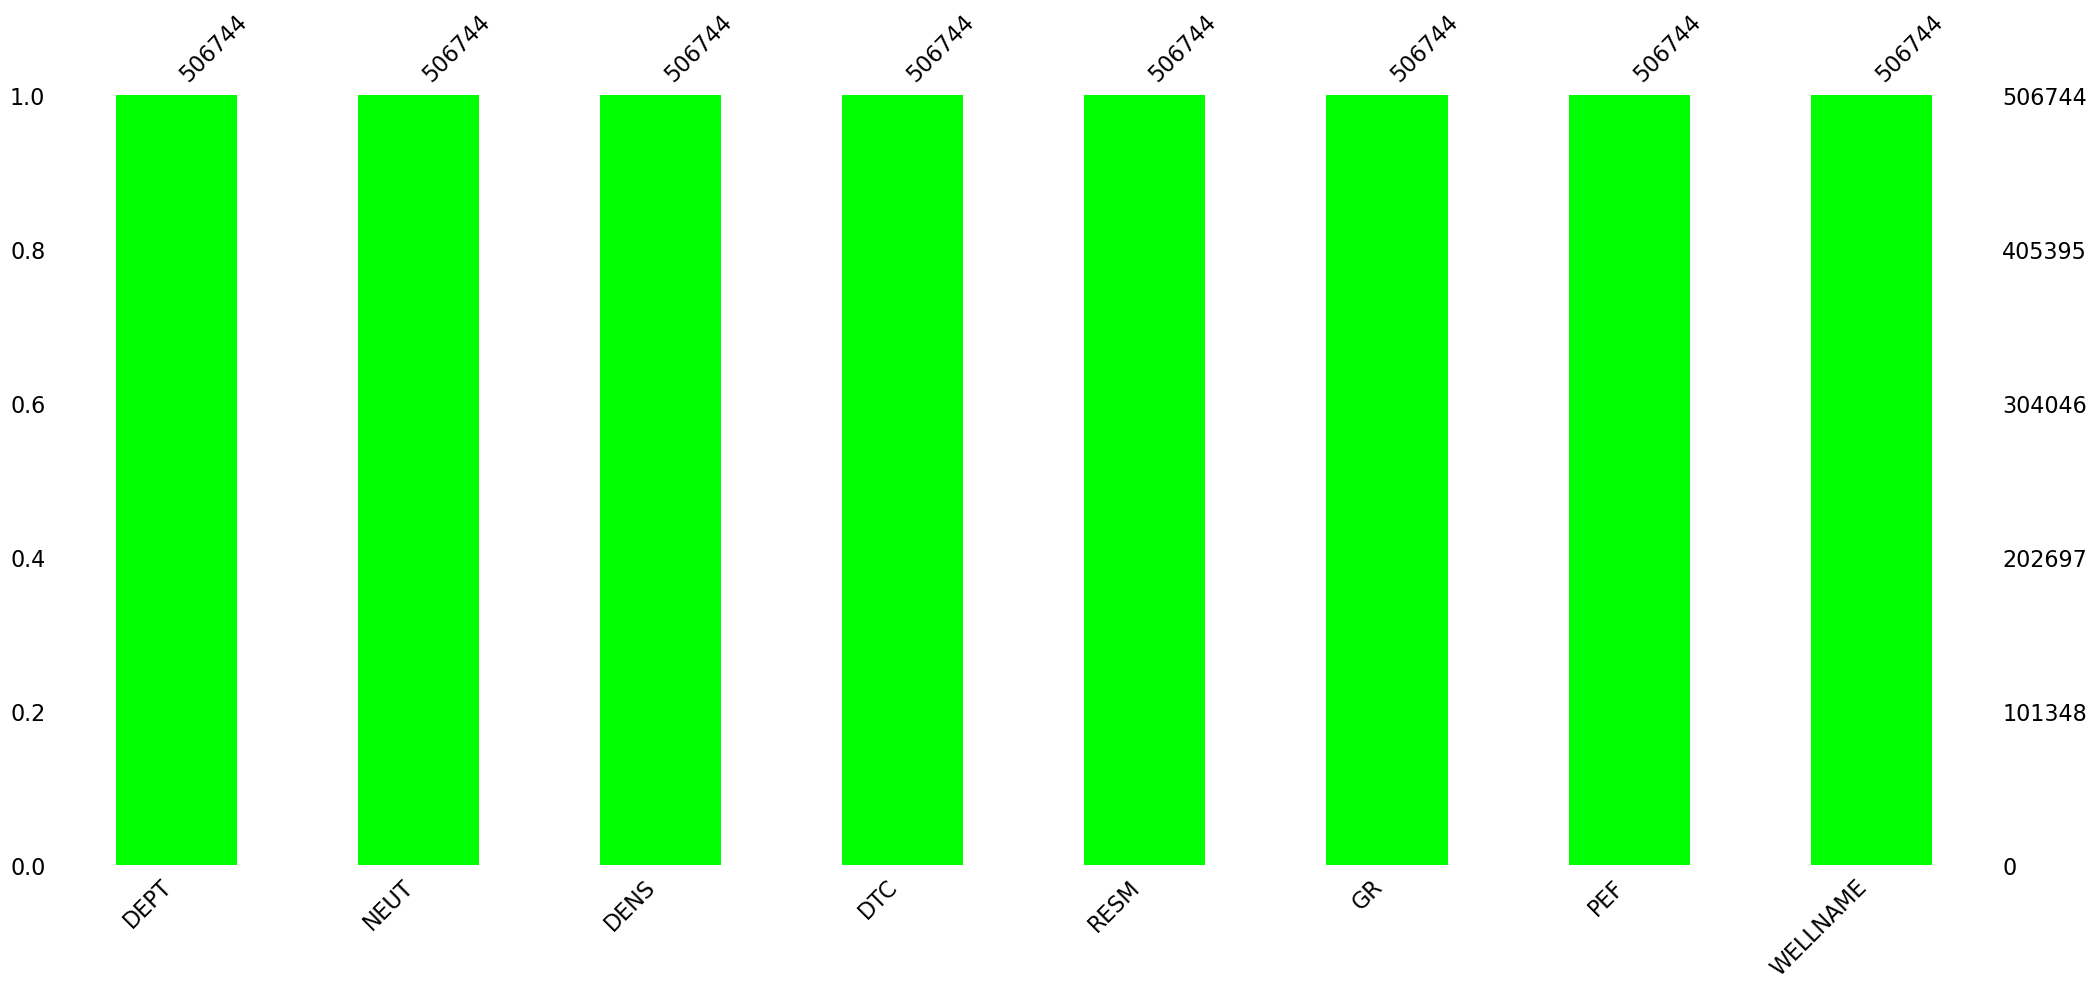

In [10]:
mno.bar(df_training, color = 'lime')

# Feature input

In [11]:
X = df_training[['DENS','DTC']]  
y = df_training['NEUT']

In [12]:
X

,DENS,DTC
0,2.2471,118.2797
1,2.2503,118.0861
2,2.2536,117.8926
3,2.2543,117.8988
4,2.2487,118.3909
...,...,...
506739,2.4787,96.4259
506740,2.4799,96.5073
506741,2.4799,96.2745
506742,2.4798,96.0416


In [13]:
y

0         0.34758
1         0.32441
2         0.30124
3         0.29313
4         0.32163
           ...   
506739    0.32734
506740    0.32727
506741    0.31979
506742    0.31231
506743    0.30483
Name: NEUT, Length: 506744, dtype: float64

# Test unseen 1 (Kapuni-16)

In [14]:
X_tw1 = test_well1[['DENS','DTC']]
y_tw1 = test_well1['NEUT']

# Test unseen 2 (Cheal-B4)

In [15]:
X_tw2 = test_well2[['DENS','DTC']]
y_tw2 = test_well2['NEUT']

# Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Transforming training data
X_trans = scaler.fit_transform(X)

# transforming test data
X_tw1_T = scaler.transform(X_tw1)
X_tw2_T = scaler.transform(X_tw2)

# Train test split

In [17]:
X_train, X_val, y_train, y_val = train_test_split(X_trans, y, test_size = 0.2)

# Model 0: DummyRegressor 
# Baseline model

In [18]:
from sklearn.dummy import DummyRegressor

In [19]:
model0 = DummyRegressor(strategy = 'median')
model0.fit(X_train, y_train)

DummyRegressor(strategy='median')

In [20]:
y_pred0 = model0.predict(X_val)

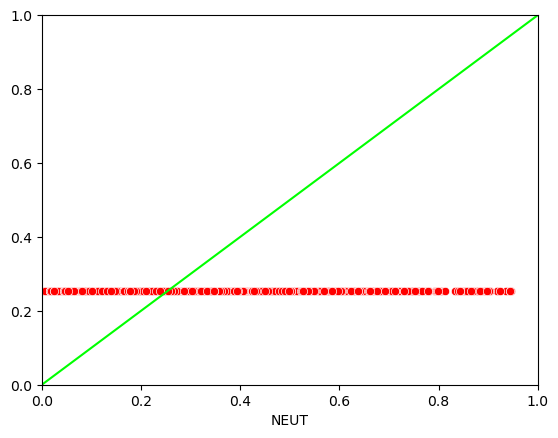

In [21]:
sns.scatterplot(x=y_val, y=y_pred0, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [22]:
mae0 = metrics.mean_absolute_error(y_val, y_pred0)
print("MAE_DR: ", mae0)

mse0 = metrics.mean_squared_error(y_val, y_pred0)
print('MSE_DR: ', mse0)

RMSE0 =mse0 ** 0.5
print('RMSE_DR: ', RMSE0)

r2_DR = metrics.r2_score(y_val,y_pred0) 
print("R2-Score DR: ",r2_DR)

MAE_DR:  0.07659073340634838
MSE_DR:  0.009646222490538633
RMSE_DR:  0.09821518462304407
R2-Score DR:  -0.008386838184085699


# Model 1 Multi Linear Regression

In [23]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

LinearRegression()

In [24]:
y_pred1 = model1.predict(X_val)

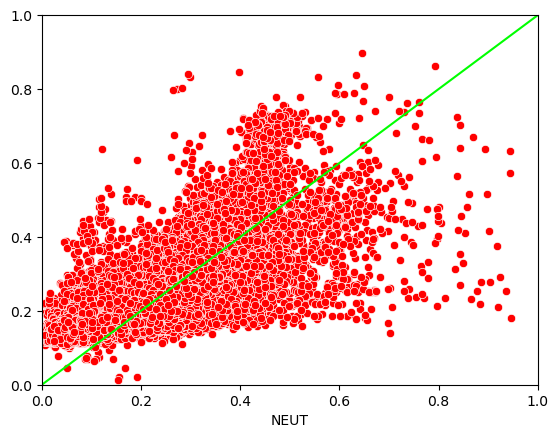

In [25]:
sns.scatterplot(x=y_val, y=y_pred1, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [26]:
y_pred1_tw1 = model1.predict(X_tw1_T)
y_pred1_tw2 = model1.predict(X_tw2_T)

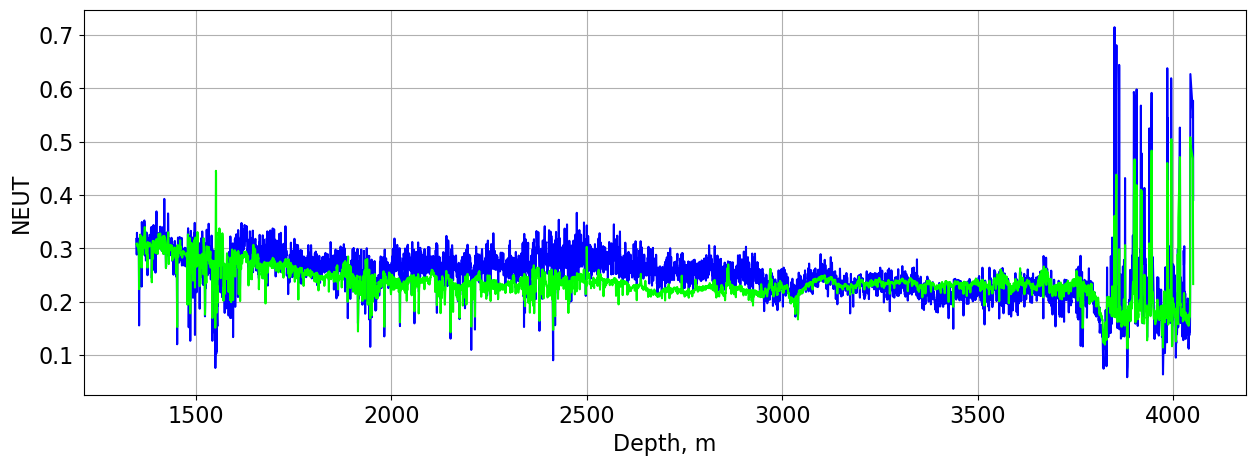

In [27]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred1_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

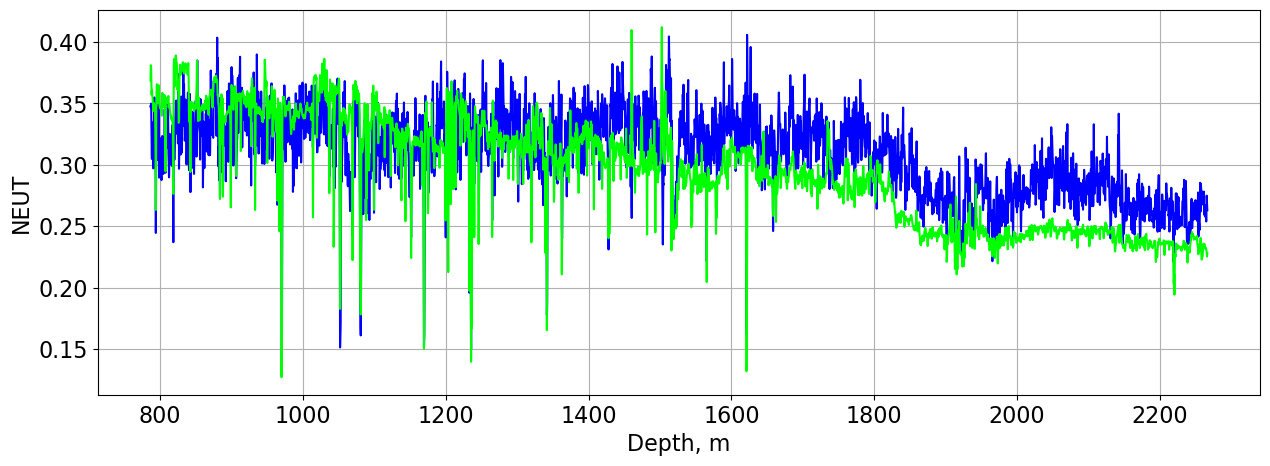

In [28]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred1_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 2: HistGradientBoostingRegressor
# Histogram-based Gradient Boosting Regression Tree.

In [29]:
model2 = HistGradientBoostingRegressor()
model2.fit(X_train, y_train)

HistGradientBoostingRegressor()

In [30]:
y_pred2 = model2.predict(X_val)

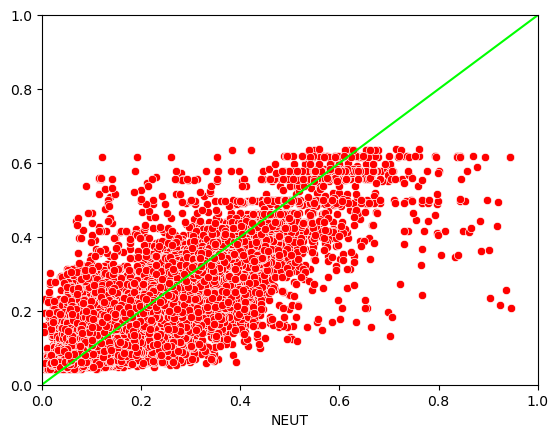

In [31]:
sns.scatterplot(x=y_val, y=y_pred2, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [32]:
y_pred2_tw1 = model2.predict(X_tw1_T)
y_pred2_tw2 = model2.predict(X_tw2_T)

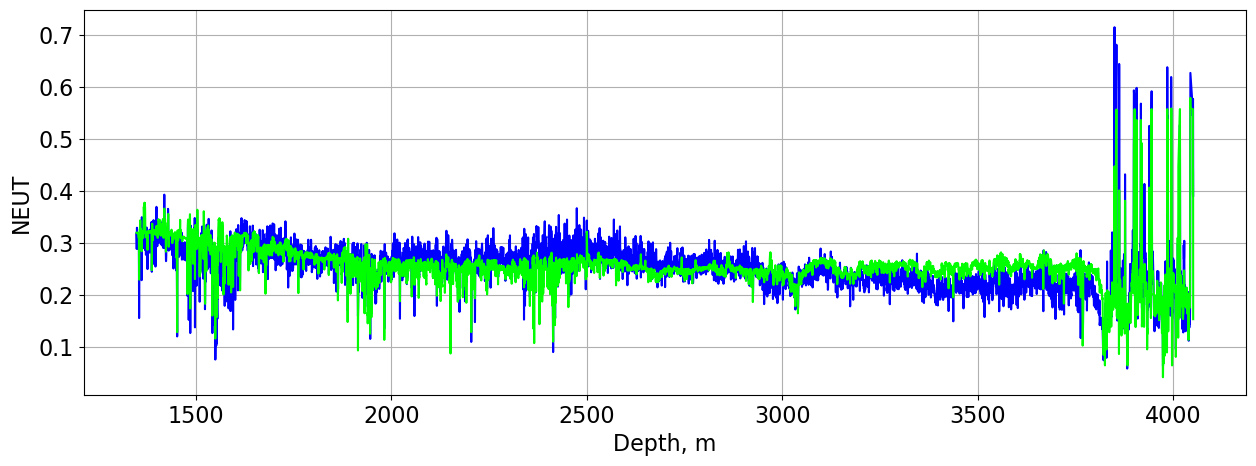

In [33]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred2_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

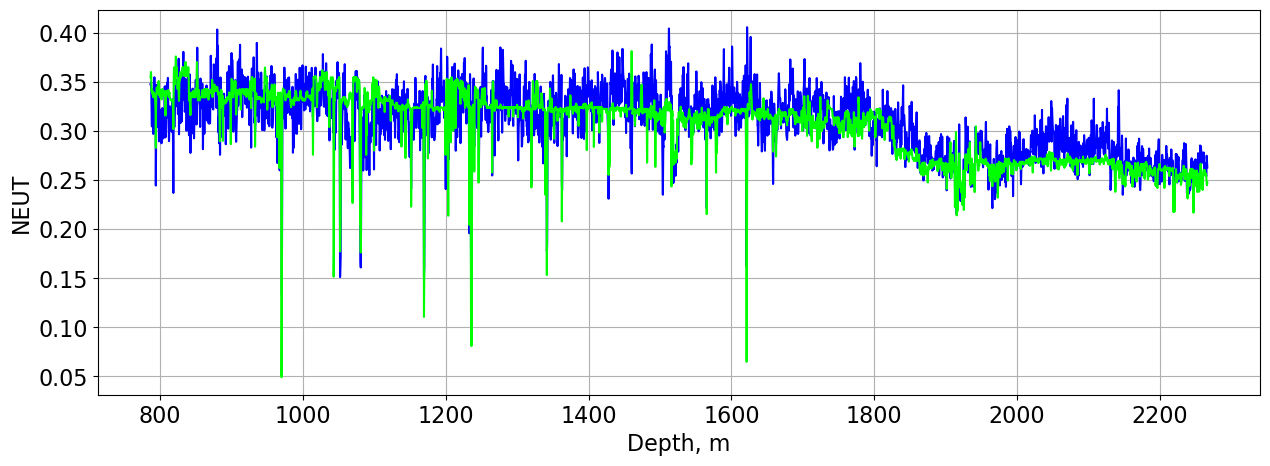

In [34]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred2_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 3: AdaBoostRegressor

In [35]:
model3 = AdaBoostRegressor()
model3.fit(X_train, y_train)

AdaBoostRegressor()

In [36]:
y_pred3 = model3.predict(X_val)

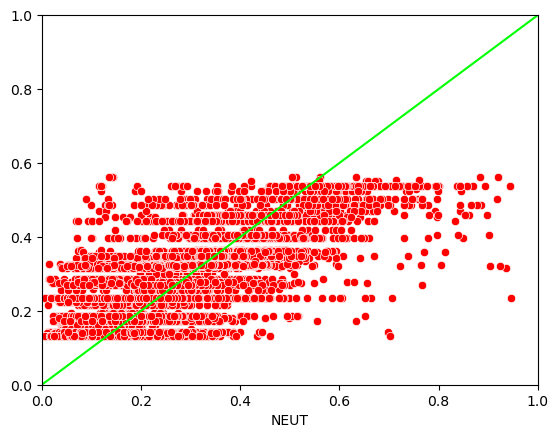

In [37]:
sns.scatterplot(x=y_val, y=y_pred3, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [38]:
y_pred3_tw1 = model3.predict(X_tw1_T)
y_pred3_tw2 = model3.predict(X_tw2_T)

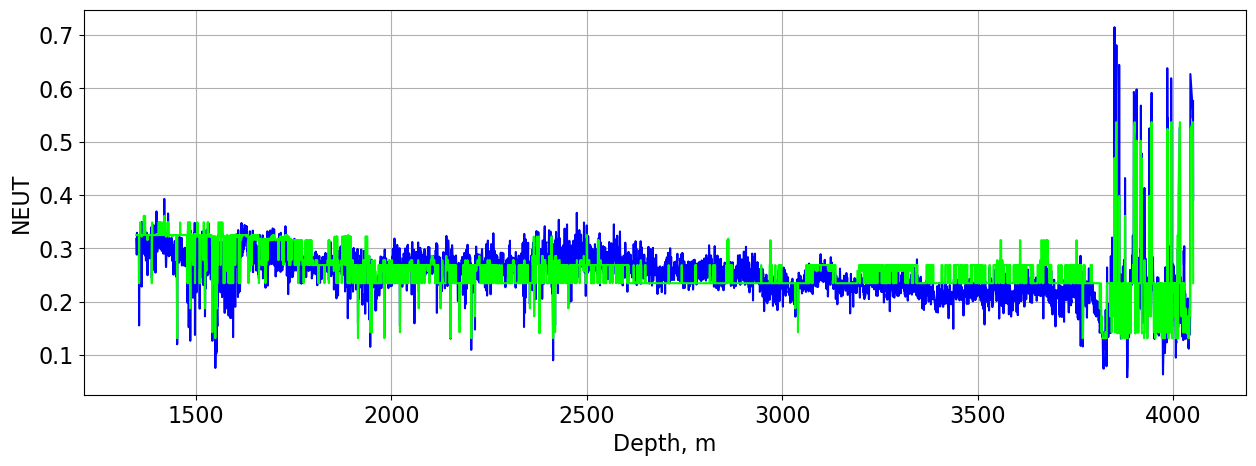

In [39]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred3_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

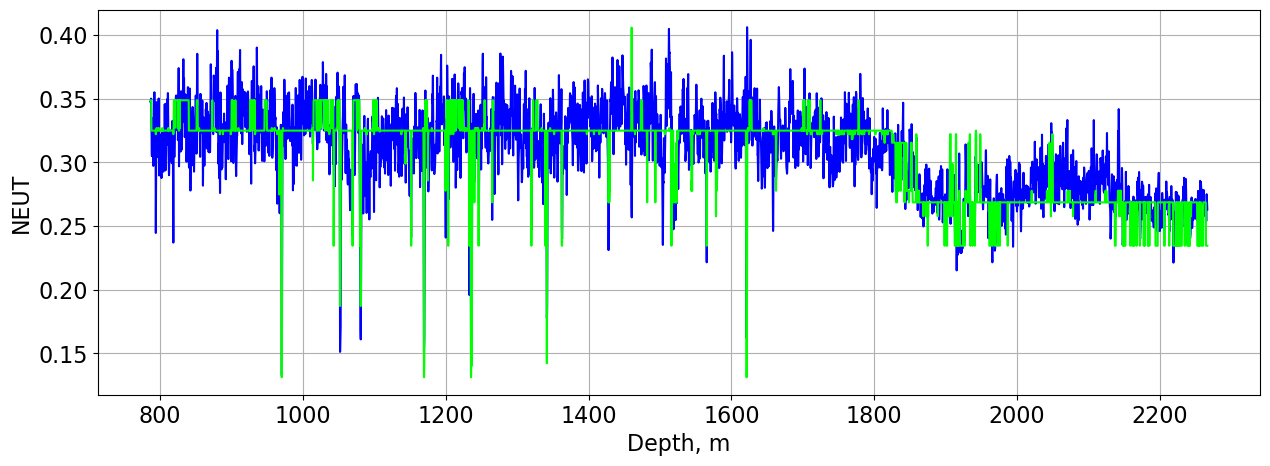

In [40]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred3_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 4: Decision Tree Regressor

In [41]:
model4 = DecisionTreeRegressor()
model4.fit(X_train, y_train)

DecisionTreeRegressor()

In [42]:
y_pred4 = model4.predict(X_val)

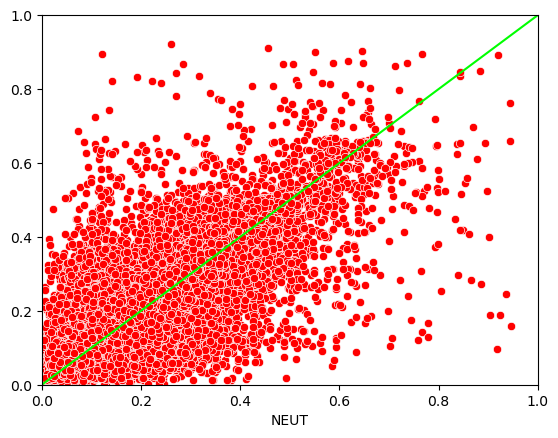

In [43]:
sns.scatterplot(x=y_val, y=y_pred4, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [44]:
y_pred4_tw1 = model4.predict(X_tw1_T)
y_pred4_tw2 = model4.predict(X_tw2_T)

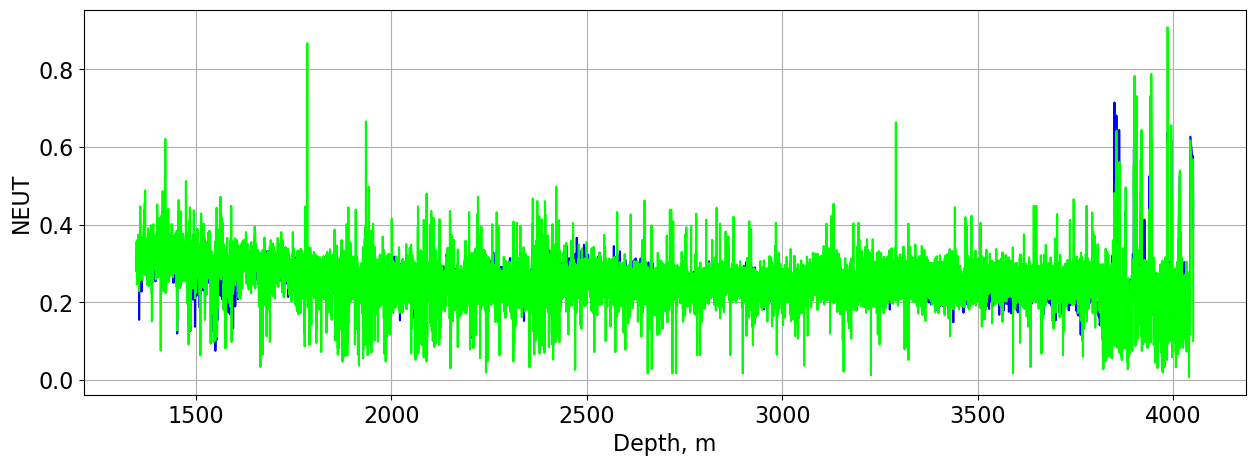

In [45]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred4_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

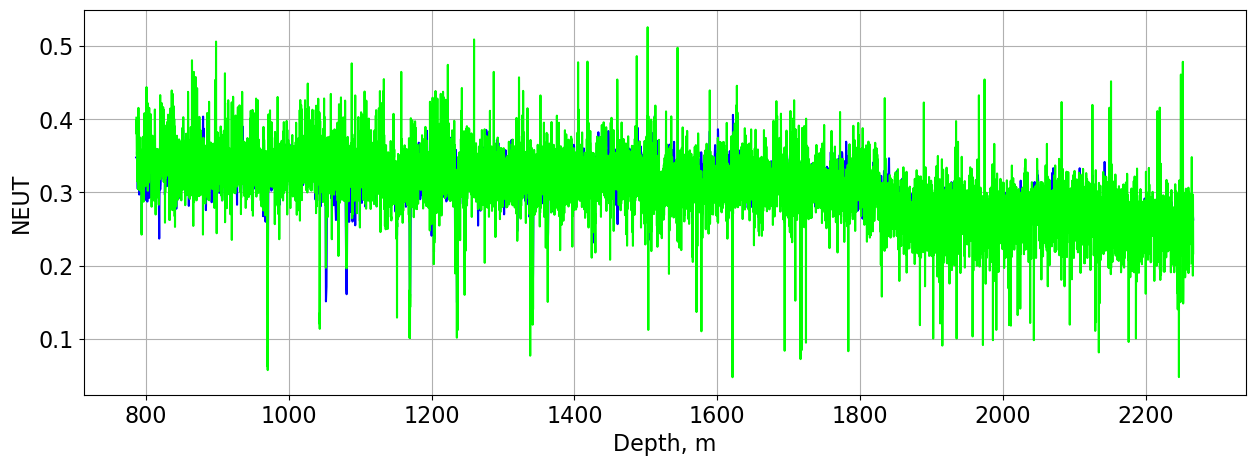

In [46]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred4_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 5: Random forest Regressor

In [47]:
model5 = RandomForestRegressor()
model5.fit(X_train, y_train)

RandomForestRegressor()

In [48]:
y_pred5 = model5.predict(X_val)

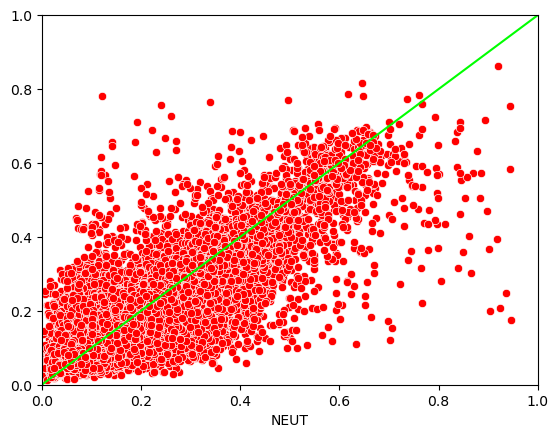

In [49]:
sns.scatterplot(x=y_val, y=y_pred5, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [50]:
y_pred5_tw1 = model5.predict(X_tw1_T)
y_pred5_tw2 = model5.predict(X_tw2_T)

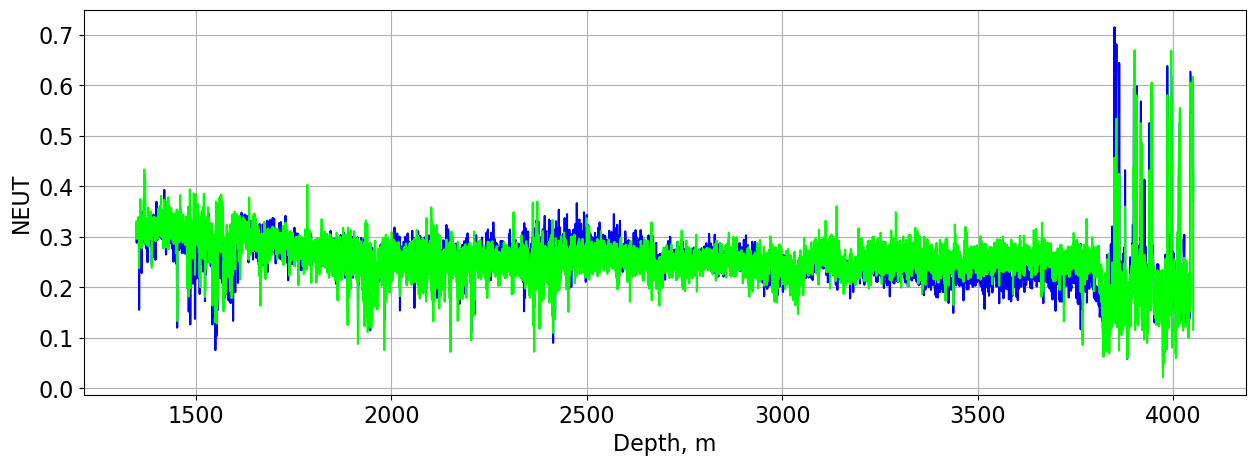

In [51]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred5_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

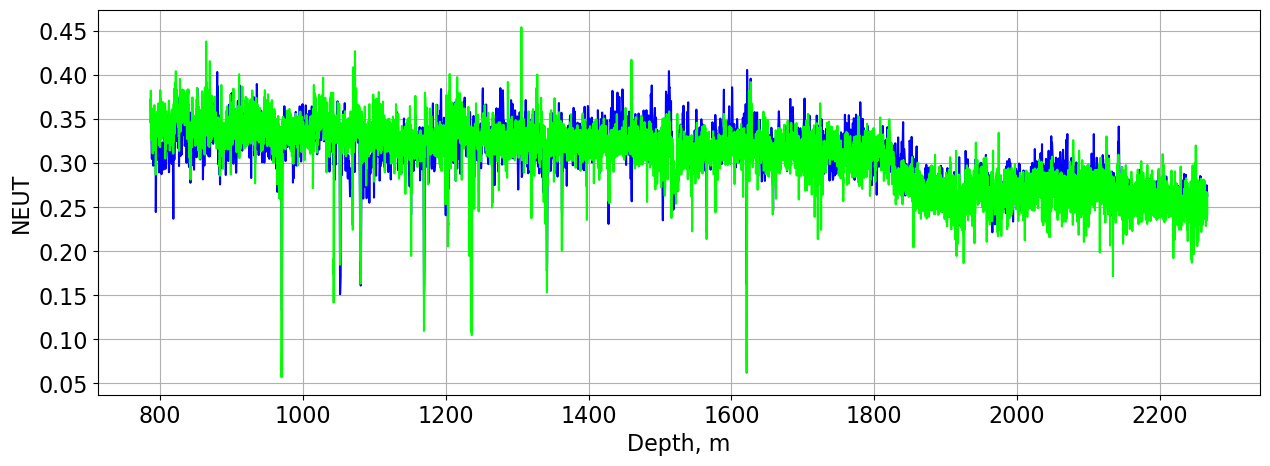

In [52]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred5_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 6: Gradient Boost Regressor

In [53]:
model6 = GradientBoostingRegressor()
model6.fit(X_train, y_train)

GradientBoostingRegressor()

In [54]:
y_pred6 = model6.predict(X_val)

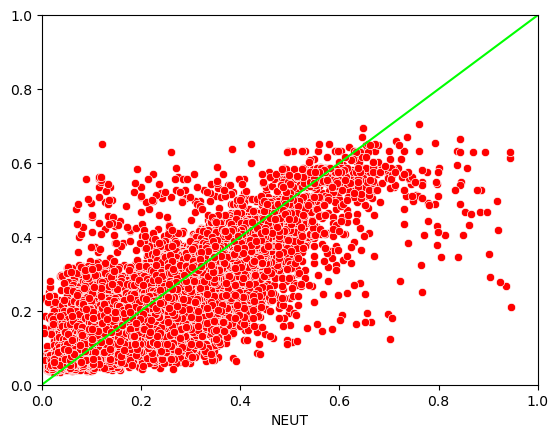

In [55]:
sns.scatterplot(x=y_val, y=y_pred6, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [56]:
y_pred6_tw1 = model6.predict(X_tw1_T)
y_pred6_tw2 = model6.predict(X_tw2_T)

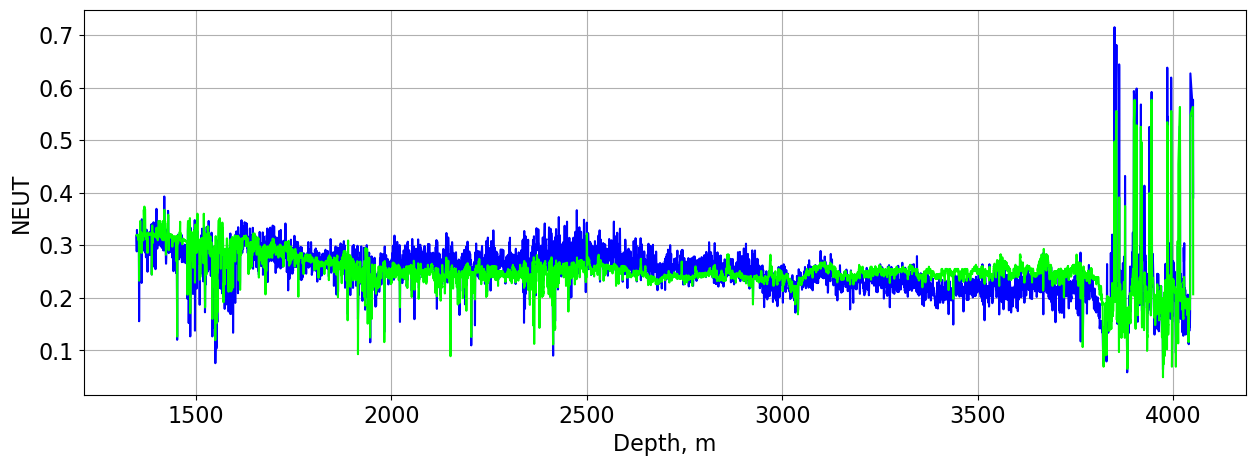

In [57]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred6_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

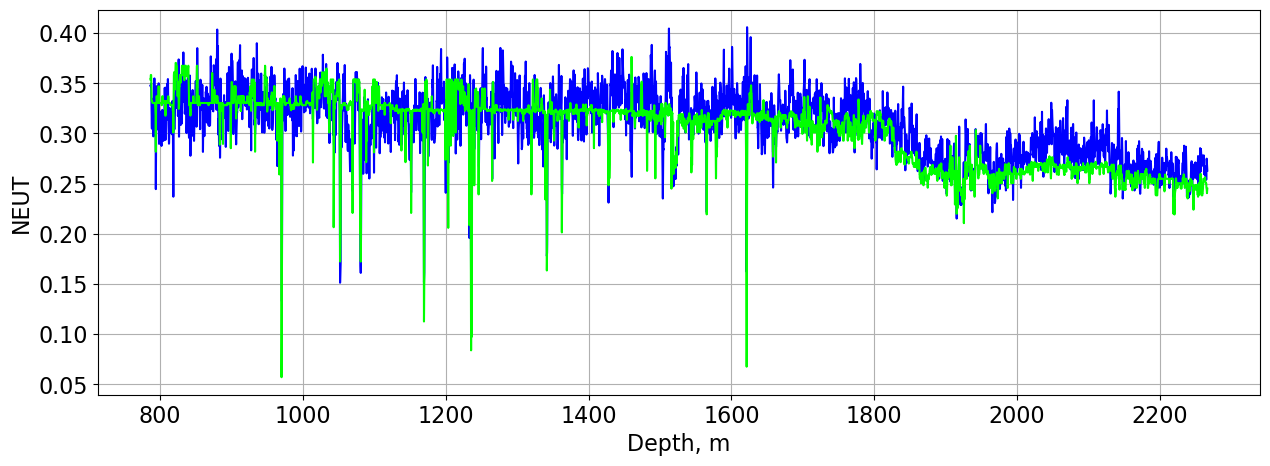

In [58]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred6_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 7: ANN

In [59]:
from tensorflow import keras

model7 = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),  
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1)
])

# Compile the model
model7.compile(loss="mse", optimizer="adam") 

model7.fit(X_train, y_train, epochs=50, batch_size=32)  

y_pred7 = model7.predict(X_val)



Epoch 1/50

12669/12669 [==============================] - 33s 2ms/step - loss: 0.0023
Epoch 2/50
12669/12669 [==============================] - 15s 1ms/step - loss: 0.0021
Epoch 3/50
12669/12669 [==============================] - 15s 1ms/step - loss: 0.0020
Epoch 4/50
12669/12669 [==============================] - 14s 1ms/step - loss: 0.0020
Epoch 5/50
12669/12669 [==============================] - 15s 1ms/step - loss: 0.0020
Epoch 6/50
12669/12669 [==============================] - 15s 1ms/step - loss: 0.0020
Epoch 7/50
12669/12669 [==============================] - 15s 1ms/step - loss: 0.0020
Epoch 8/50
12669/12669 [==============================] - 15s 1ms/step - loss: 0.0020
Epoch 9/50
12669/12669 [==============================] - 15s 1ms/step - loss: 0.0020
Epoch 10/50
12669/12669 [==============================] - 15s 1ms/step - loss: 0.0020
Epoch 11/50
12669/12669 [==============================] - 15s 1ms/step - loss: 0.0020
Epoch 12/50
12669/12669 [========================

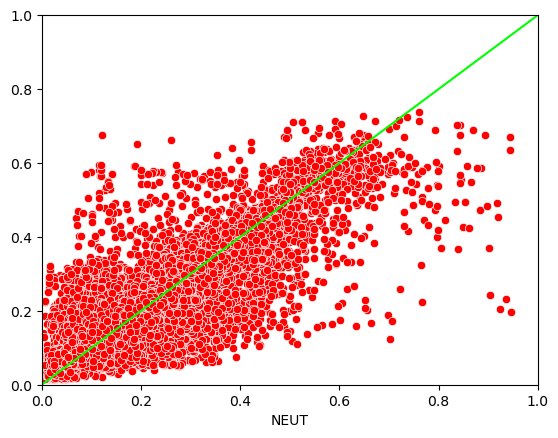

In [60]:
sns.scatterplot(x=y_val, y=y_pred7.reshape(1,-1)[0], color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [61]:
y_pred7_tw1 = model7.predict(X_tw1_T)
y_pred7_tw2 = model7.predict(X_tw2_T)

304/304 [==============================] - 0s 921us/step


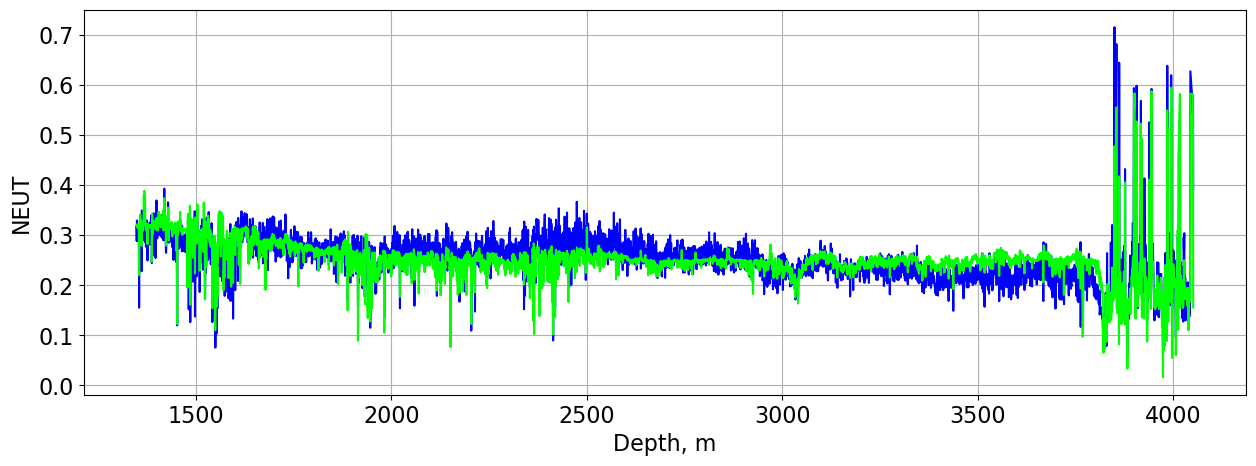

In [62]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred7_tw1.reshape(1,-1)[0], label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

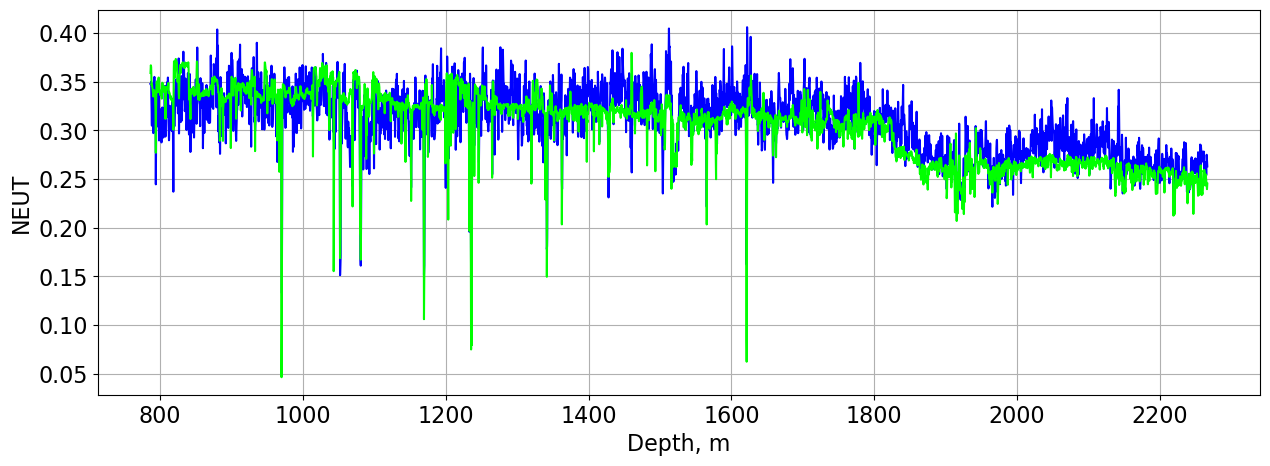

In [63]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred7_tw2.reshape(1,-1)[0], label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 8: Bagging Regressor

In [64]:
model8 = BaggingRegressor()
model8.fit(X_train, y_train)

BaggingRegressor()

In [65]:
y_pred8 = model8.predict(X_val)

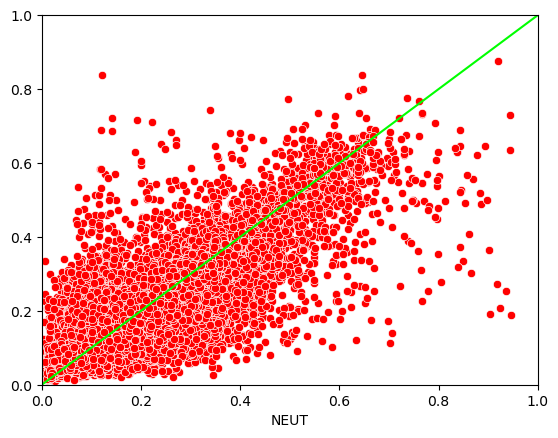

In [66]:
sns.scatterplot(x=y_val, y=y_pred8, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [67]:
y_pred8_tw1 = model8.predict(X_tw1_T)
y_pred8_tw2 = model8.predict(X_tw2_T)

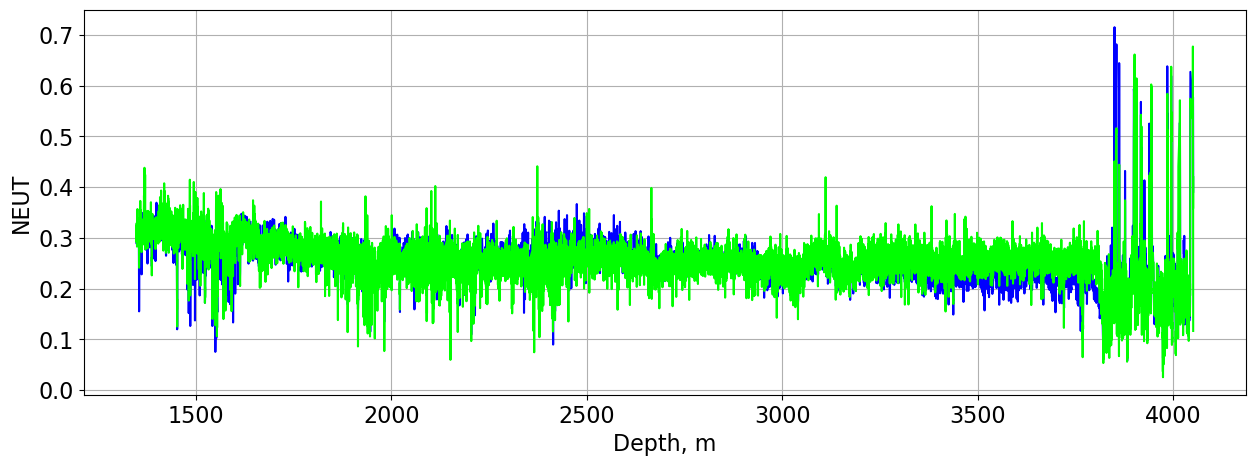

In [68]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred8_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

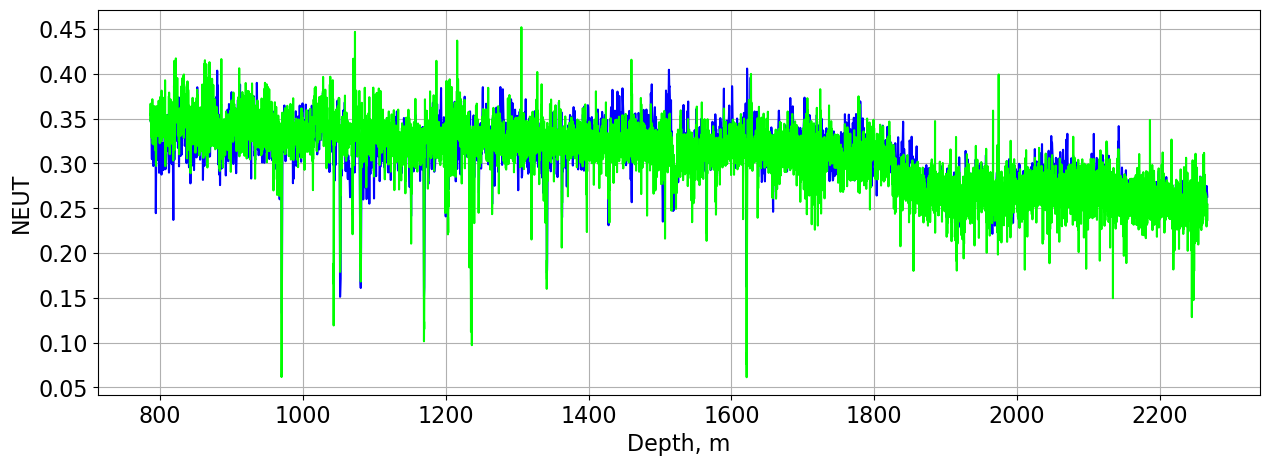

In [69]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred8_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 9: LGBMRegressor

In [70]:
from lightgbm import LGBMRegressor
model9 = LGBMRegressor()
model9.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010364 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 405395, number of used features: 2
[LightGBM] [Info] Start training from score 0.243130


LGBMRegressor()

In [71]:
y_pred9 = model9.predict(X_val)

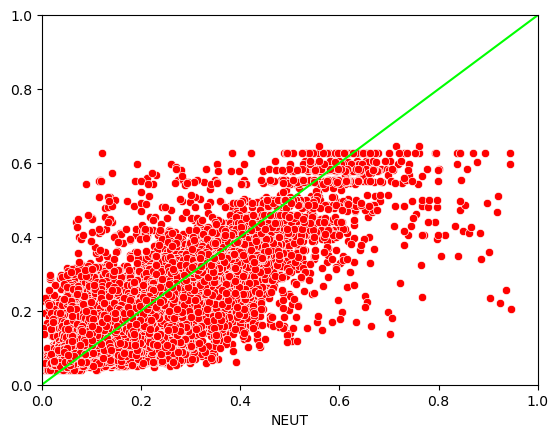

In [72]:
sns.scatterplot(x=y_val, y=y_pred9, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [73]:
y_pred9_tw1 = model9.predict(X_tw1_T)
y_pred9_tw2 = model9.predict(X_tw2_T)

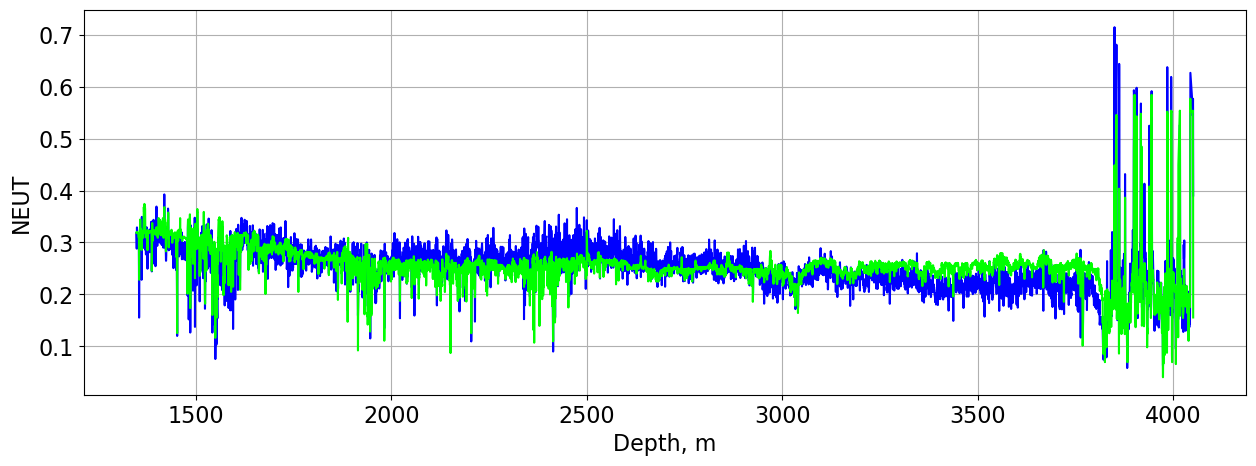

In [74]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred9_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

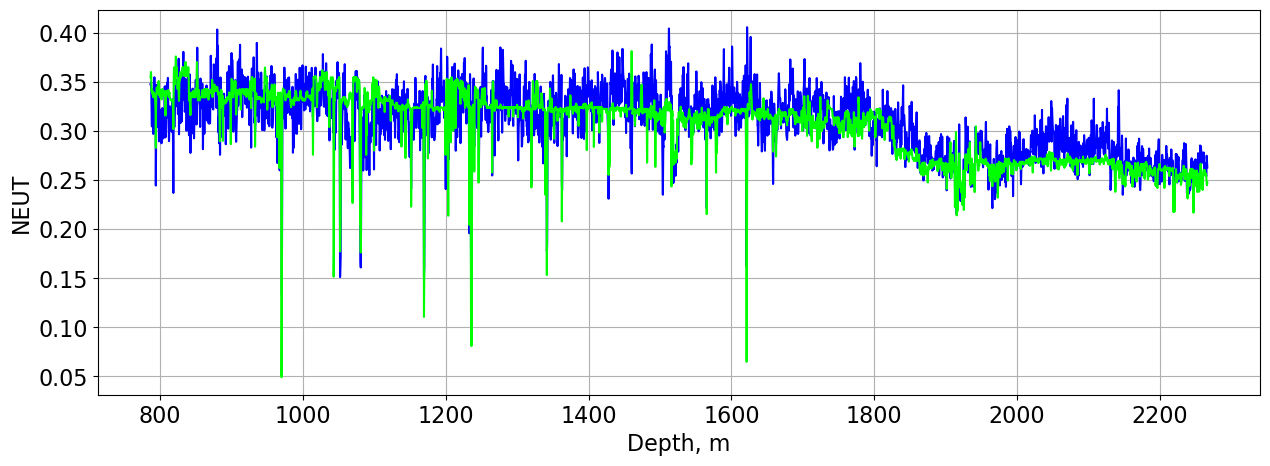

In [75]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred2_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Saving results

In [76]:
# Saving model results of 20% test data

model_val  = {'y_val':y_val, 'y_pred1': y_pred1, 'y_pred2': y_pred2, 'y_pred3': y_pred3, 
              'y_pred4': y_pred4, 'y_pred5': y_pred5, 'y_pred6': y_pred6,
              'y_pred7': y_pred7.reshape(1,-1)[0], 'y_pred8': y_pred8, 'y_pred9': y_pred9}
model_results_val = pd.DataFrame(data = model_val)
model_results_val.to_csv(#, index =False)
print(model_results_val)

          y_val   y_pred1   y_pred2   y_pred3  y_pred4   y_pred5   y_pred6  \
178483  0.06978  0.171228  0.079346  0.142316  0.10798  0.067116  0.092109   
270297  0.26598  0.242420  0.267640  0.268538  0.31141  0.297216  0.261155   
355087  0.26582  0.191712  0.222102  0.234505  0.24245  0.223699  0.223414   
181379  0.18393  0.192250  0.199883  0.234505  0.18475  0.204530  0.205336   
116414  0.17339  0.189331  0.190761  0.234505  0.18012  0.188098  0.192501   
...         ...       ...       ...       ...      ...       ...       ...   
485851  0.33208  0.225046  0.251156  0.234505  0.21887  0.242651  0.244195   
271492  0.25452  0.215531  0.241963  0.234505  0.24028  0.250655  0.237347   
281039  0.30304  0.294941  0.319334  0.324810  0.28710  0.324654  0.318393   
322112  0.34797  0.332674  0.342583  0.348636  0.41174  0.385690  0.345501   
352899  0.23755  0.187186  0.222828  0.234505  0.18038  0.220938  0.221406   

         y_pred7   y_pred8   y_pred9  
178483  0.077741  0.0665

In [77]:
X_tw1

,DENS,DTC
0,2.3449,101.9751
1,2.3467,101.9682
2,2.3484,101.9612
3,2.3502,101.9543
4,2.3500,101.9740
...,...,...
17657,1.5591,112.5611
17658,1.6938,100.8119
17659,1.8634,91.5144
17660,2.0968,86.6845


In [78]:
# Saving model results of test well1

model_tw1  = {'test_well1 DEPT':test_well1['DEPT'],"y_tw1":y_tw1,
              'y_pred1_tw1': y_pred1_tw1, 'y_pred2_tw1': y_pred2_tw1, 'y_pred3_tw1': y_pred3_tw1, 
              'y_pred4_tw1': y_pred4_tw1, 'y_pred5_tw1': y_pred5_tw1, 'y_pred6_tw1': y_pred6_tw1,
              'y_pred7_tw1': y_pred7_tw1.reshape(1,-1)[0], 'y_pred8_tw1': y_pred8_tw1, 'y_pred9_tw1': y_pred9_tw1}
model_results_tw1 = pd.DataFrame(data = model_tw1)
model_results_tw1.to_csv(#, index =False)
print(model_results_tw1)

       test_well1 DEPT    y_tw1  y_pred1_tw1  y_pred2_tw1  y_pred3_tw1  \
0            1347.5208  0.31750     0.308051     0.319469     0.324810   
1            1347.6732  0.31446     0.307948     0.319469     0.324810   
2            1347.8256  0.31144     0.307849     0.319469     0.324810   
3            1347.9780  0.30841     0.307746     0.319469     0.324810   
4            1348.1304  0.30205     0.307829     0.319469     0.324810   
...                ...      ...          ...          ...          ...   
17657        4051.2492  0.56273     0.381603     0.391705     0.501909   
17658        4051.4016  0.57694     0.331562     0.441408     0.441935   
17659        4051.5540  0.55670     0.289264     0.397345     0.398038   
17660        4051.7064  0.47368     0.261067     0.389275     0.398106   
17661        4051.8588  0.39066     0.232870     0.153080     0.234505   

       y_pred4_tw1  y_pred5_tw1  y_pred6_tw1  y_pred7_tw1  y_pred8_tw1  \
0          0.31753     0.330305     0

In [79]:
# Saving model results of test well2
model_tw2 = {'test_well2 DEPT':test_well2['DEPT'],"y_tw2":y_tw2,
              'y_pred1_tw2': y_pred1_tw2, 'y_pred2_tw2': y_pred2_tw2, 'y_pred3_tw2': y_pred3_tw2, 
              'y_pred4_tw2': y_pred4_tw2, 'y_pred5_tw2': y_pred5_tw2, 'y_pred6_tw2': y_pred6_tw2,
              'y_pred7_tw2': y_pred7_tw2.reshape(1,-1)[0], 'y_pred8_tw2': y_pred8_tw2, 'y_pred9_tw2': y_pred9_tw2}
model_results_tw2 = pd.DataFrame(data=model_tw2)
model_results_tw2.to_csv(#, index=False)
print(model_results_tw2)


      test_well2 DEPT    y_tw2  y_pred1_tw2  y_pred2_tw2  y_pred3_tw2  \
0            786.5364  0.34774     0.368633     0.354914     0.348636   
1            786.6888  0.34742     0.372824     0.355128     0.348636   
2            786.8412  0.34709     0.377019     0.356385     0.348636   
3            786.9936  0.34677     0.381214     0.360214     0.348636   
4            787.1460  0.34777     0.380687     0.360214     0.348636   
...               ...      ...          ...          ...          ...   
9701        2265.8832  0.27157     0.226095     0.245863     0.234505   
9702        2266.0356  0.26976     0.225241     0.244864     0.234505   
9703        2266.1880  0.26751     0.226183     0.245863     0.234505   
9704        2266.3404  0.26526     0.227120     0.245863     0.234505   
9705        2266.4928  0.26301     0.228062     0.247757     0.234505   

      y_pred4_tw2  y_pred5_tw2  y_pred6_tw2  y_pred7_tw2  y_pred8_tw2  \
0         0.40209     0.372168     0.353856     0.

# Model Evaluation

In [80]:
mae_list = []
mse_list = []
rmse_list = []
maxerr_list = []
mape_list = []
r2_list = []
adj_r2_list = []

# evaluation on the 20% data split
model_list = ['Multi-LinearRegression','HistGradientBoosting','AdaBoost', 'DecisionTree', 'RandomForest', 
              'GradientBoosting', 'ANN', 'BaggingRegressor', 'LightGBM']
for i in [y_pred1,y_pred2,y_pred3,y_pred4,y_pred5, y_pred6,y_pred7,y_pred8, y_pred9]:
    mae = metrics.mean_absolute_error(y_val, i)
    mse = metrics.mean_squared_error(y_val, i)
    rmse = mse**0.5
    maxerr = metrics.max_error(y_val,i)
    mape = metrics.mean_absolute_percentage_error(y_val,i)
    r2 = metrics.r2_score(y_val,i)
    adj_r2 = 1 - ((1 - r2) * ((X.shape[0] - 1) / (X.shape[0] - X.shape[1] - 1)))
    mae_list.append(mae)
    mse_list.append(mse)
    rmse_list.append(rmse)
    maxerr_list.append(maxerr)
    mape_list.append(mape)
    r2_list.append(r2)
    adj_r2_list.append(adj_r2)
    

model_eval = {'Algorithm': model_list, 'MAE': mae_list, 'MSE': mse_list, 
              'RMSE': rmse_list, 'Max Error': maxerr_list, 'MAPE': mape_list, 'R2 score': r2_list, 'Adjusted R2': adj_r2_list}


model_eval_results = pd.DataFrame(data=model_eval)
model_eval_results.to_csv(#, index=False)
print(model_eval_results)


                Algorithm       MAE       MSE      RMSE  Max Error      MAPE  \
0  Multi-LinearRegression  0.044161  0.003727  0.061046   0.763713  0.349526   
1    HistGradientBoosting  0.030823  0.002040  0.045168   0.738554  0.197974   
2                AdaBoost  0.039961  0.003094  0.055627   0.710695  0.327646   
3            DecisionTree  0.043568  0.004034  0.063511   0.822240  0.265129   
4            RandomForest  0.033368  0.002361  0.048590   0.769926  0.210843   
5        GradientBoosting  0.031619  0.002102  0.045846   0.734050  0.206310   
6                     ANN  0.031106  0.002069  0.045488   0.748695  0.193400   
7        BaggingRegressor  0.034536  0.002521  0.050208   0.757003  0.217107   
8                LightGBM  0.030823  0.002041  0.045182   0.739217  0.197894   

   R2 score  Adjusted R2  
0  0.610430     0.610428  
1  0.786729     0.786728  
2  0.676530     0.676529  
3  0.578331     0.578330  
4  0.753188     0.753187  
5  0.780281     0.780280  
6  0.78370

In [81]:
model_eval_results

,Algorithm,MAE,MSE,RMSE,Max Error,MAPE,R2 score,Adjusted R2
0,Multi-LinearRegression,0.044161,0.003727,0.061046,0.763713,0.349526,0.610430,0.610428
1,HistGradientBoosting,0.030823,0.002040,0.045168,0.738554,0.197974,0.786729,0.786728
2,AdaBoost,0.039961,0.003094,0.055627,0.710695,0.327646,0.676530,0.676529
3,DecisionTree,0.043568,0.004034,0.063511,0.822240,0.265129,0.578331,0.578330
4,RandomForest,0.033368,0.002361,0.048590,0.769926,0.210843,0.753188,0.753187
5,GradientBoosting,0.031619,0.002102,0.045846,0.734050,0.206310,0.780281,0.780280
6,ANN,0.031106,0.002069,0.045488,0.748695,0.193400,0.783701,0.783700
7,BaggingRegressor,0.034536,0.002521,0.050208,0.757003,0.217107,0.736483,0.736482
8,LightGBM,0.030823,0.002041,0.045182,0.739217,0.197894,0.786601,0.786601


In [82]:
mae_list_tw1 = []
mse_list_tw1 = []
rmse_list_tw1 = []
maxerr_list_tw1 = []
mape_list_tw1 = []
r2_list_tw1 = []
adj_r2_list_tw1 = []

for i in [y_pred1_tw1, y_pred2_tw1, y_pred3_tw1, y_pred4_tw1, y_pred5_tw1, y_pred6_tw1, y_pred7_tw1, y_pred8_tw1, y_pred9_tw1]:
    mae_tw1 = metrics.mean_absolute_error(y_tw1, i)
    mse_tw1 = metrics.mean_squared_error(y_tw1, i)
    rmse_tw1 = mse_tw1 ** 0.5
    maxerr_tw1 = metrics.max_error(y_tw1, i)
    mape_tw1 = metrics.mean_absolute_percentage_error(y_tw1, i)
    r2_tw1 = metrics.r2_score(y_tw1, i)
    adj_r2_tw1 = 1 - ((1 - r2_tw1) * ((X.shape[0] - 1) / (X.shape[0] - X.shape[1] - 1)))

    mae_list_tw1.append(mae_tw1)
    mse_list_tw1.append(mse_tw1)
    rmse_list_tw1.append(rmse_tw1)
    maxerr_list_tw1.append(maxerr_tw1)
    mape_list_tw1.append(mape_tw1)
    r2_list_tw1.append(r2_tw1)
    adj_r2_list_tw1.append(adj_r2_tw1)

model_list_tw1 = model_list

model_eval_tw1 = {'Algorithm': model_list_tw1, 'MAE': mae_list_tw1, 'MSE': mse_list_tw1, 
                  'RMSE': rmse_list_tw1, 'Max Error': maxerr_list_tw1, 
                  'MAPE': mape_list_tw1, 'R2 score': r2_list_tw1, 'Adjusted R2': adj_r2_list_tw1}

model_eval_results_tw1 = pd.DataFrame(data=model_eval_tw1)
model_eval_results_tw1.to_csv(#, index=False)
print(model_eval_results_tw1)

                Algorithm       MAE       MSE      RMSE  Max Error      MAPE  \
0  Multi-LinearRegression  0.025745  0.001132  0.033648   0.354027  0.101901   
1    HistGradientBoosting  0.022819  0.000837  0.028926   0.267686  0.096103   
2                AdaBoost  0.026145  0.001057  0.032509   0.246074  0.110433   
3            DecisionTree  0.035881  0.002463  0.049628   0.587780  0.150666   
4            RandomForest  0.025951  0.001116  0.033409   0.304497  0.109012   
5        GradientBoosting  0.022902  0.000812  0.028490   0.253246  0.095250   
6                     ANN  0.022480  0.000812  0.028491   0.246085  0.093425   
7        BaggingRegressor  0.027155  0.001238  0.035188   0.298129  0.114062   
8                LightGBM  0.022796  0.000836  0.028910   0.266080  0.096018   

   R2 score  Adjusted R2  
0  0.423367     0.423365  
1  0.573856     0.573854  
2  0.461737     0.461735  
3 -0.254355    -0.254360  
4  0.431554     0.431551  
5  0.586617     0.586615  
6  0.58658

In [83]:
model_results_tw1

,test_well1 DEPT,y_tw1,y_pred1_tw1,y_pred2_tw1,y_pred3_tw1,y_pred4_tw1,y_pred5_tw1,y_pred6_tw1,y_pred7_tw1,y_pred8_tw1,y_pred9_tw1
0,1347.5208,0.31750,0.308051,0.319469,0.324810,0.31753,0.330305,0.318585,0.318276,0.323929,0.318978
1,1347.6732,0.31446,0.307948,0.319469,0.324810,0.32638,0.306380,0.318585,0.317903,0.298561,0.318978
2,1347.8256,0.31144,0.307849,0.319469,0.324810,0.32356,0.317395,0.318585,0.317550,0.314918,0.318978
3,1347.9780,0.30841,0.307746,0.319469,0.324810,0.27837,0.295622,0.318585,0.317177,0.291264,0.318978
4,1348.1304,0.30205,0.307829,0.319469,0.324810,0.28783,0.302290,0.318585,0.317245,0.299453,0.318978
...,...,...,...,...,...,...,...,...,...,...,...
17657,4051.2492,0.56273,0.381603,0.391705,0.501909,0.52921,0.473898,0.520857,0.512473,0.461385,0.467947
17658,4051.4016,0.57694,0.331562,0.441408,0.441935,0.47200,0.450371,0.486921,0.470414,0.469539,0.442851
17659,4051.5540,0.55670,0.289264,0.397345,0.398038,0.44528,0.369166,0.410222,0.425283,0.357591,0.398395
17660,4051.7064,0.47368,0.261067,0.389275,0.398106,0.46103,0.434201,0.361485,0.378918,0.421479,0.390732


In [84]:
mae_list_tw2 = []
mse_list_tw2 = []
rmse_list_tw2 = []
maxerr_list_tw2 = []
mape_list_tw2 = []
r2_list_tw2 = []
adj_r2_list_tw2 = []


for i in [y_pred1_tw2, y_pred2_tw2, y_pred3_tw2, y_pred4_tw2, y_pred5_tw2, y_pred6_tw2, y_pred7_tw2, y_pred8_tw2, y_pred9_tw2]:
    mae_tw2 = metrics.mean_absolute_error(y_tw2, i)
    mse_tw2 = metrics.mean_squared_error(y_tw2, i)
    rmse_tw2 = mse_tw2 ** 0.5
    maxerr_tw2 = metrics.max_error(y_tw2, i)
    mape_tw2 = metrics.mean_absolute_percentage_error(y_tw2, i)
    r2_tw2 = metrics.r2_score(y_tw2, i)
    adj_r2_tw2 = 1 - ((1 - r2_tw2) * ((X.shape[0] - 1) / (X.shape[0] - X.shape[1] - 1)))

    mae_list_tw2.append(mae_tw2)
    mse_list_tw2.append(mse_tw2)
    rmse_list_tw2.append(rmse_tw2)
    maxerr_list_tw2.append(maxerr_tw2)
    mape_list_tw2.append(mape_tw2)
    r2_list_tw2.append(r2_tw2)
    adj_r2_list_tw2.append(adj_r2_tw2)


model_list_tw2 = model_list

model_eval_tw2 = {'Algorithm': model_list_tw2, 'MAE': mae_list_tw2, 'MSE': mse_list_tw2, 
                  'RMSE': rmse_list_tw2, 'Max Error': maxerr_list_tw2, 
                  'MAPE': mape_list_tw2, 'R2 score': r2_list_tw2, 'Adjusted R2': adj_r2_list_tw2}

model_eval_results_tw2 = pd.DataFrame(data=model_eval_tw2)
model_eval_results_tw2.to_csv(#, index=False)
# Print the results
print(model_eval_results_tw2)


                Algorithm       MAE       MSE      RMSE  Max Error      MAPE  \
0  Multi-LinearRegression  0.027856  0.001069  0.032703   0.169046  0.091058   
1    HistGradientBoosting  0.016923  0.000476  0.021806   0.166812  0.055104   
2                AdaBoost  0.016632  0.000462  0.021504   0.171435  0.054725   
3            DecisionTree  0.028888  0.001496  0.038674   0.263180  0.095080   
4            RandomForest  0.019849  0.000662  0.025726   0.176597  0.064887   
5        GradientBoosting  0.017573  0.000495  0.022242   0.161948  0.057249   
6                     ANN  0.018200  0.000532  0.023059   0.163018  0.059350   
7        BaggingRegressor  0.020948  0.000746  0.027315   0.199125  0.068587   
8                LightGBM  0.017085  0.000482  0.021951   0.162839  0.055648   

   R2 score  Adjusted R2  
0 -0.038190    -0.038194  
1  0.538419     0.538417  
2  0.551114     0.551113  
3 -0.451868    -0.451873  
4  0.357547     0.357544  
5  0.519783     0.519781  
6  0.48384

In [85]:
model_results_tw2

,test_well2 DEPT,y_tw2,y_pred1_tw2,y_pred2_tw2,y_pred3_tw2,y_pred4_tw2,y_pred5_tw2,y_pred6_tw2,y_pred7_tw2,y_pred8_tw2,y_pred9_tw2
0,786.5364,0.34774,0.368633,0.354914,0.348636,0.40209,0.372168,0.353856,0.358920,0.354947,0.354626
1,786.6888,0.34742,0.372824,0.355128,0.348636,0.38017,0.345577,0.353856,0.361534,0.366732,0.354507
2,786.8412,0.34709,0.377019,0.356385,0.348636,0.39926,0.361625,0.358331,0.364167,0.347442,0.356740
3,786.9936,0.34677,0.381214,0.360214,0.348636,0.37151,0.382492,0.358331,0.366800,0.355587,0.356740
4,787.1460,0.34777,0.380687,0.360214,0.348636,0.35359,0.359551,0.358331,0.366324,0.345572,0.356740
...,...,...,...,...,...,...,...,...,...,...,...
9701,2265.8832,0.27157,0.226095,0.245863,0.234505,0.23763,0.249871,0.242306,0.240497,0.254539,0.246557
9702,2266.0356,0.26976,0.225241,0.244864,0.234505,0.18637,0.251080,0.240508,0.239583,0.253241,0.246940
9703,2266.1880,0.26751,0.226183,0.245863,0.234505,0.29712,0.266901,0.242306,0.241457,0.254867,0.247357
9704,2266.3404,0.26526,0.227120,0.245863,0.234505,0.24404,0.256279,0.242306,0.243362,0.236000,0.247357


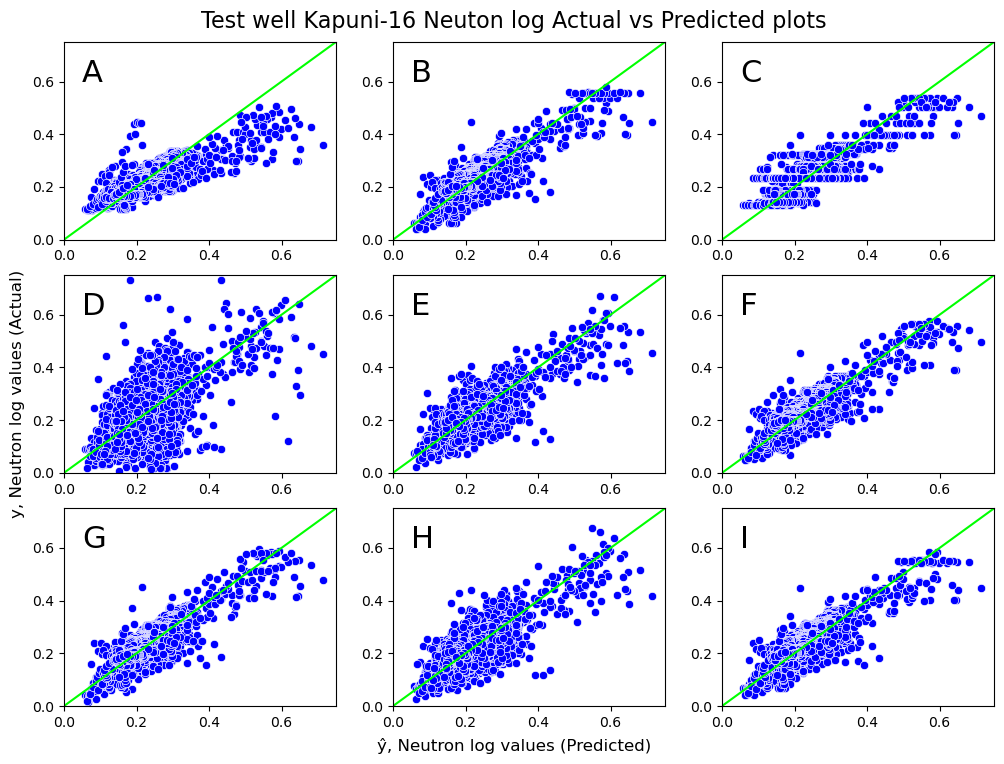

In [86]:
fig = plt.figure(figsize=(12, 8))

# Define colors and font size
scatter_color = 'blue'
line_color = 'lime'
font_size = 16

# Subplot 1
ax1 = fig.add_subplot(3, 3, 1)
sns.scatterplot(x=y_tw1, y=y_pred1_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "A", fontsize=22)

# Subplot 2
ax2 = fig.add_subplot(3, 3, 2)
sns.scatterplot(x=y_tw1, y=y_pred2_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "B", fontsize=22)

# Subplot 3
ax3 = fig.add_subplot(3, 3, 3)
sns.scatterplot(x=y_tw1, y=y_pred3_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "C", fontsize=22)

# Subplot 4
ax4 = fig.add_subplot(3, 3, 4)
sns.scatterplot(x=y_tw1, y=y_pred4_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "D", fontsize=22)

# Subplot 5
ax5 = fig.add_subplot(3, 3, 5)
sns.scatterplot(x=y_tw1, y=y_pred5_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "E", fontsize=22)

# Subplot 6
ax6 = fig.add_subplot(3, 3, 6)
sns.scatterplot(x=y_tw1, y=y_pred6_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "F", fontsize=22)

# Subplot 7
ax7 = fig.add_subplot(3, 3, 7)
sns.scatterplot(x=y_tw1, y=y_pred7_tw1.reshape(1, -1)[0], color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "G", fontsize=22)

# Subplot 8
ax8 = fig.add_subplot(3, 3, 8)
sns.scatterplot(x=y_tw1, y=y_pred8_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "H", fontsize=22)

# Subplot 9
ax9 = fig.add_subplot(3, 3, 9)
sns.scatterplot(x=y_tw1, y=y_pred9_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "I", fontsize=22)

fig.suptitle('Test well Kapuni-16 Neuton log Actual vs Predicted plots', fontsize  = 16)
fig.supylabel('y, Neutron log values (Actual)',x = 0.08, y =0.5, fontsize = 12)
fig.supxlabel('ŷ, Neutron log values (Predicted)', x = 0.5,y = 0.05,fontsize = 12)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.21, hspace=0.18)
fig.subplots_adjust(top=0.94)

# Adjust layout
# fig.tight_layout()

plt.savefig('well logs results test_well1.png', dpi = 1200,  bbox_inches='tight')
# plt.show()

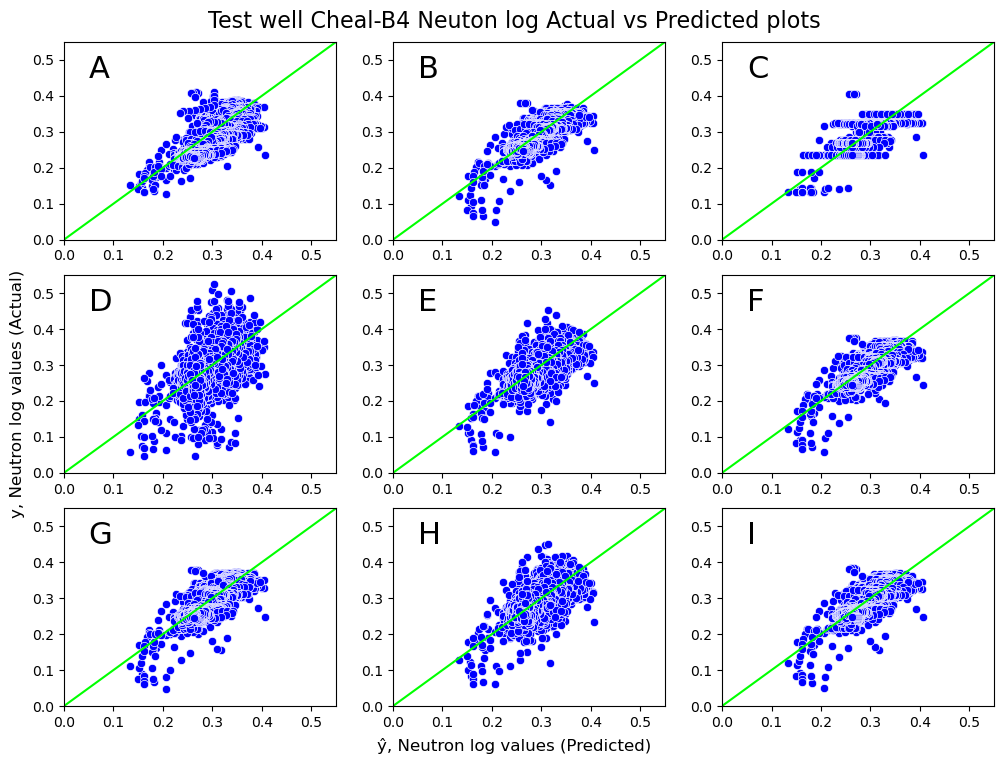

In [87]:
fig = plt.figure(figsize=(12, 8))

# Define colors and font size
scatter_color = 'blue'
line_color = 'lime'
font_size = 16

# Subplot 1
ax1 = fig.add_subplot(3, 3, 1)
sns.scatterplot(x=y_tw2, y=y_pred1_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "A", fontsize=22)

# Subplot 2
ax2 = fig.add_subplot(3, 3, 2)
sns.scatterplot(x=y_tw2, y=y_pred2_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "B", fontsize=22)

# Subplot 3
ax3 = fig.add_subplot(3, 3, 3)
sns.scatterplot(x=y_tw2, y=y_pred3_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "C", fontsize=22)

# Subplot 4
ax4 = fig.add_subplot(3, 3, 4)
sns.scatterplot(x=y_tw2, y=y_pred4_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "D", fontsize=22)

# Subplot 5
ax5 = fig.add_subplot(3, 3, 5)
sns.scatterplot(x=y_tw2, y=y_pred5_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "E", fontsize=22)

# Subplot 6
ax6 = fig.add_subplot(3, 3, 6)
sns.scatterplot(x=y_tw2, y=y_pred6_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "F", fontsize=22)

# Subplot 7
ax7 = fig.add_subplot(3, 3, 7)
sns.scatterplot(x=y_tw2, y=y_pred7_tw2.reshape(1, -1)[0], color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "G", fontsize=22)

# Subplot 8
ax8 = fig.add_subplot(3, 3, 8)
sns.scatterplot(x=y_tw2, y=y_pred8_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "H", fontsize=22)

# Subplot 9
ax9 = fig.add_subplot(3, 3, 9)
sns.scatterplot(x=y_tw2, y=y_pred9_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "I", fontsize=22)

fig.suptitle('Test well Cheal-B4 Neuton log Actual vs Predicted plots', fontsize=16)
fig.supylabel('y, Neutron log values (Actual)', x=0.08, y=0.5, fontsize=12)
fig.supxlabel('ŷ, Neutron log values (Predicted)', x=0.5, y=0.05, fontsize=12)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.21, hspace=0.18)
fig.subplots_adjust(top=0.94)

# Adjust layout
# fig.tight_layout()

plt.savefig('act vs pred test_well2.png', dpi = 1200,  bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 24))

# Define colors and font size
actual_color = 'blue'
predicted_color = 'red'
fontsize_title = 18
fontsize_ticks = 16
font_figmark = 22
legend_font = 14 

# Plot for Model 1: Multi-linear regression
plt.subplot(9, 1, 1)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred1_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Multi-linear regression', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'A', fontsize=font_figmark)
plt.grid()

# Plot for Model 2: Hist Gradient Boost Regressor
plt.subplot(9, 1, 2)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred2_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Hist Gradient Boost Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'B', fontsize=font_figmark)
plt.grid()

# Plot for Model 3: Adaboost Regressor
plt.subplot(9, 1, 3)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred3_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Adaboost Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'C', fontsize=font_figmark)
plt.grid()

# Plot for Model 4: Decision Tree Regressor
plt.subplot(9, 1, 4)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred4_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Decision Tree Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'D', fontsize=font_figmark)
plt.grid()

# Plot for Model 5: Random Forest Regressor
plt.subplot(9, 1, 5)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred5_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Random Forest Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'E', fontsize=font_figmark)
plt.grid()

# Plot for Model 6: Gradient Boost Regressor
plt.subplot(9, 1, 6)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred6_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Gradient Boost Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'F', fontsize=font_figmark)
plt.grid()

# Plot for Model 7: Artificial Neural Networks
plt.subplot(9, 1, 7)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred7_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Artificial Neural Networks', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'G', fontsize=font_figmark)
plt.grid()

# Plot for Model 8: Bagging Regressor
plt.subplot(9, 1, 8)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred8_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Bagging Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'H', fontsize=font_figmark)
plt.grid()

# Plot for Model 9: Light GBM
plt.subplot(9, 1, 9)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred9_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Light GBM', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'I', fontsize=font_figmark)
plt.legend(fontsize = legend_font,loc= 'upper left')
plt.grid()

plt.tight_layout()

plt.savefig('well logs results test_well1.png', dpi = 1200,  bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 24))

# Define colors and font size
actual_color = 'blue'
predicted_color = 'red'
fontsize_title = 18
fontsize_ticks = 16
legend_font = 14
font_figmark = 22

# Plot for Model 1: Multi-linear regression
plt.subplot(9, 1, 1)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred1_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Multi-linear regression', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'A', fontsize=font_figmark)
plt.grid()

# Plot for Model 2: Hist Gradient Boost Regressor
plt.subplot(9, 1, 2)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred2_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Hist Gradient Boost Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'B', fontsize=font_figmark)
plt.grid()

# Plot for Model 3: Adaboost Regressor
plt.subplot(9, 1, 3)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred3_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Adaboost Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'C', fontsize=font_figmark)
plt.grid()

# Plot for Model 4: Decision Tree Regressor
plt.subplot(9, 1, 4)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred4_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Decision Tree Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'D', fontsize=font_figmark)
plt.grid()

# Plot for Model 5: Random Forest Regressor
plt.subplot(9, 1, 5)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred5_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Random Forest Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'E', fontsize=font_figmark)
plt.grid()

# Plot for Model 6: Gradient Boost Regressor
plt.subplot(9, 1, 6)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred6_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Gradient Boost Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'F', fontsize=font_figmark)
plt.grid()

# Plot for Model 7: Artificial Neural Networks
plt.subplot(9, 1, 7)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred7_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Artificial Neural Networks', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'G', fontsize=font_figmark)
plt.grid()

# Plot for Model 8: Bagging Regressor
plt.subplot(9, 1, 8)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred8_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Bagging Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'H', fontsize=font_figmark)
plt.grid()

# Plot for Model 9: Light GBM
plt.subplot(9, 1, 9)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred9_tw2, label='ŷ, Predicted NEUT', color=predicted_color)

plt.title('Model: Light GBM', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'I', fontsize=font_figmark)
plt.grid()
plt.legend(fontsize = legend_font)

plt.tight_layout()

plt.savefig('well logs results test_well2.png', dpi = 1200,  bbox_inches='tight')
plt.show()
